In [3]:
import numpy as np

In [4]:
# Parameter
tau = 0.1                   # Zeitkonstante: Wie schnell klingt die Impulsantwort ab? tau klein -> schnell, tau groß -> langsam
omega_g = 5 / tau           # Grenzfrequenz: Wie viel von der Übertragungsfunktion betrachten wir noch? 
T = 0.1 * np.pi / omega_g   # Abtastperiode: Abstasttheorem muss erfüllt sein: ws =2*pi/T --> T = (2*pi)/ws. Shannon: ws>2wg --> T<pi/wg
N = 10_000                  # Anzahl Samples: wie viele Abtastpunkte gibt es?

In [9]:
# c)
# requenz Schrittweite
delta_omega = (2 * np.pi) / (N * T)

# Frequenzbasis
omega_disk = np.arange(N) * delta_omega

# diskrete Übertragungsfunktion
H_disk = -1 / (1 + 1j * omega_disk * tau)

# zum Vergleich: kontinuierliche Übertragungsfunktion
# omega = np.arange(0,1000,0.001)
# omega = np.linspace(0,1000,100000);
omega_cont = np.logspace(-3,3,1000) # geht NUR für die Visualisierung des "kontinuierlichen" Spektrums. Bei FT wird linearer Abstand benötigt
H_cont = -1 / (1 + 1j * omega_cont * tau)

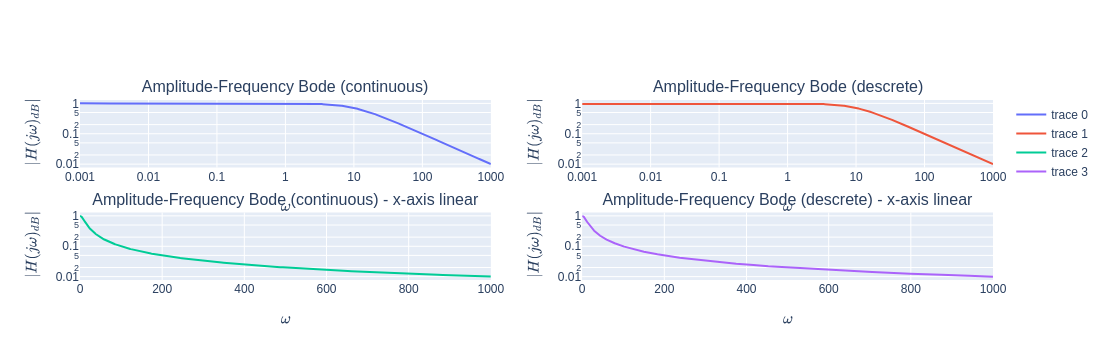

In [46]:
import plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

# plotly.offline.init_notebook_mode()
display(HTML(
    '<script type="text/javascript" async src="https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.1/MathJax.js?config=TeX-MML-AM_SVG"></script>'
))

fig = make_subplots(
    rows=2, cols=2,
    specs=[
        [{}, {}],
        [{}, {}],
    ],
    subplot_titles = [
        'Amplitude-Frequency Bode (continuous)',
        'Amplitude-Frequency Bode (descrete)',
        'Amplitude-Frequency Bode (continuous) - x-axis linear',
        'Amplitude-Frequency Bode (descrete) - x-axis linear',
    ]
)

fig.add_trace(
    go.Scatter(
        x = omega_cont,
        y = np.abs(H_cont),
    ), row=1, col=1
)
fig.add_trace(
    go.Scatter(
        x = omega_disk,
        y = np.abs(H_disk),
    ), row=1, col=2
)
fig.add_trace(
    go.Scatter(
        x = omega_cont,
        y = np.abs(H_cont),
    ), row=2, col=1
)
fig.add_trace(
    go.Scatter(
        x = omega_disk,
        y = np.abs(H_disk),
    ), row=2, col=2
)
r1 = [-3, 3]
r2 = [10**i for i in r1]
fig.update_layout(
    # height=800,
    xaxis1=dict(title=r'$\omega$', type="log", range=r1),
    xaxis2=dict(title=r'$\omega$', type="log", range=r1),
    xaxis3=dict(title=r'$\omega$', range=r2),
    xaxis4=dict(title=r'$\omega$', range=r2),
    yaxis1=dict(title=r'$|H(j\omega)_{dB}|$', type="log"),
    yaxis2=dict(title=r'$|H(j\omega)_{dB}|$', type="log"),
    yaxis3=dict(title=r'$|H(j\omega)_{dB}|$', type="log"),
    yaxis4=dict(title=r'$|H(j\omega)_{dB}|$', type="log"),
)
fig.show()

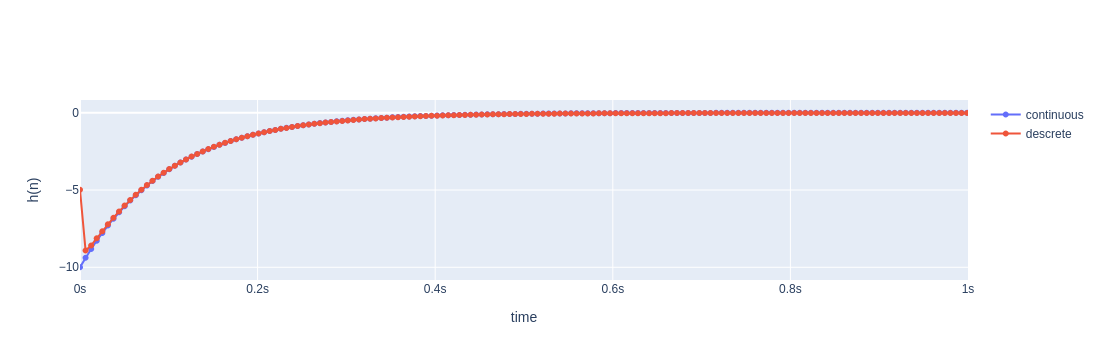

In [41]:
# d) 
# Berechne Impulsantwort aus Übertragungsfunktion 
# mit inverser Fouriertransformation

# # Option 1: manuel
# h = np.zeros(N, dtype=complex)
# for n in range(N):
#    h[n] = np.sum(H_disk * np.exp(1.0 * 1j * n * np.arange(N) * 2 * np.pi / N))

# Option 2: mit einer Toolbox
from scipy.fft import ifft
h = ifft(H_disk)

h = np.real(h)  # richtige Gewichtung
h = h / (T / 2) # auf richtige Zeitbasis beziehen

# Zeitbasis
t = np.arange(N) * T

# kontinuierliche "Lösung"
h_cont = -1 / tau * np.exp(-t / tau)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=t,
        y=h_cont,
        name='continuous',
        mode='lines+markers'
    )
)
fig.add_trace(
    go.Scatter(
        x=t,
        y=h,
        name='descrete',
        mode='lines+markers'
    )
)
fig.update_layout(
    # height=800,
    xaxis=dict(
        title='time', 
        ticksuffix='s',
        range=[0, 1],
    ),
    yaxis=dict(
        title='h(n)', 
        # type="log"
    ),
)
fig.show()